In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sm import NeuralNet
from tune_sm import find_control_voltages_1D
import optuna

device = 'cuda'
print(device)

cuda


In [19]:
def target_function(t: torch.Tensor):
    
    N = t.shape[0]
    m = nn.ELU()
    
    return 0.1*t**2 + torch.sin(3*t)

def normalize_over_range(x):
    z = (x - x.mean()) / (x.std() + 1e-8) 
    return z

def forward_whole_range(model, param_list, input_idx, v_min, v_max, N):

    in_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

    c_volt = torch.tensor(param_list, dtype=torch.float32).expand(N, -1)
    c_volt_l = c_volt[:, :input_idx]
    c_volt_r = c_volt[:, input_idx:]

    input_tensor = torch.cat([c_volt_l, in_range, c_volt_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().numpy()

    return y_out

In [6]:
state_dict = torch.load("/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_vMB_n_a=200.pth", map_location="cpu", weights_only=False)
print(state_dict['args'])

x_mean = state_dict['args']['x_mean']
x_std = state_dict['args']['x_std']
y_mean = state_dict['args']['y_mean']
y_std = state_dict['args']['y_std']
layer_dims = state_dict['args']['layer_dims']

model = NeuralNet(layer_dims, x_mean, x_std, y_mean, y_std)

model.load_state_dict(state_dict['model_state_dict'])
model.eval()

{'data_dir': PosixPath('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB'), 'num_batches': 150, 'batch_size': 512, 'x_mean': array([ 0.00020001, -0.00186806,  0.00114154,  0.00077222, -0.00031955,
        0.00164707, -0.0003422 ]), 'x_std': array([0.86578984, 0.86572622, 0.86658345, 0.86600969, 0.86579268,
       0.86567603, 0.86556896]), 'y_mean': np.float64(-0.034452119477253726), 'y_std': np.float64(0.1472368632136552), 'layer_dims': [7, 128, 128, 128, 1], 'num_epochs': 300, 'lr': 0.001, 'save_name': PosixPath('/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_vMB_n_a=200')}


NeuralNet(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [15]:
N = 100
in_range = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
target = target_function(in_range)

study = find_control_voltages_1D(
    model=model, 
    target=target, 
    N=N, 
    c_volt_min=-1.5, 
    c_volt_max=1.5, 
    in_volt_min=-1.5, 
    in_volt_max=1.5, 
    input_idx=0, 
    n_startup_trials=500, 
    n_trials=1000, 
    PRINT_EVERY=100
)

print("Best value:", study.best_value)
print("Best params:", study.best_params)  

best_vals = []

for v in study.best_params.items():
    best_vals.append(v[1])
print(best_vals)

0] Finished with score:  1.167924
100] Finished with score:  1.316928
200] Finished with score:  1.522189
300] Finished with score:  1.498271
400] Finished with score:  1.818628
500] Finished with score:  0.949704
600] Finished with score:  1.097718
700] Finished with score:  0.707362
800] Finished with score:  2.532543
900] Finished with score:  1.985744
Best value: 0.3830394744873047
Best params: {'x_0': -0.04882795762572184, 'x_1': -1.1605649293799967, 'x_2': -0.8064586332752925, 'x_3': -0.3523085796740256, 'x_4': -1.4946667155001003, 'x_5': -0.08541378931740967}
[-0.04882795762572184, -1.1605649293799967, -0.8064586332752925, -0.3523085796740256, -1.4946667155001003, -0.08541378931740967]


TypeError: forward_whole_range() missing 1 required positional argument: 'N'

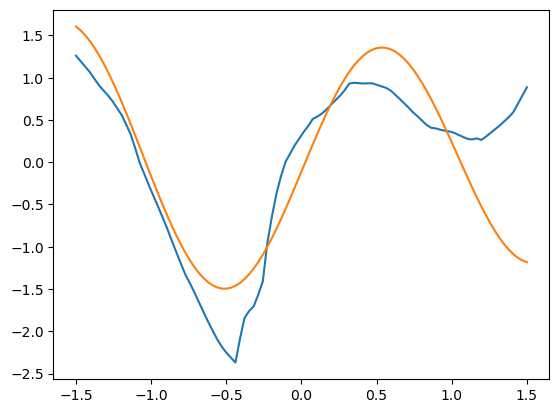

In [23]:
y_out = forward_whole_range(model, best_vals, 0, -1.5, 1.5, N) 

y_norm = normalize_over_range(y_out)
t_norm = normalize_over_range(target)

plt.plot(in_range, y_norm)
plt.plot(in_range, t_norm)